In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

In [29]:
df = pd.read_csv("indian_roads_dataset.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (20000, 24)
   accident_id        city        state   latitude  longitude        date  \
0            0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   

    time  hour day_of_week  is_weekend  ... visibility  temperature  \
0   5:00     5      Sunday           1  ...        low           32   
1   4:00     4      Sunday           1  ...       high           34   
2  13:00    13   Wednesday           0  ...        low           21   
3  11:00    11      Sunday           1  ...        low           30   
4  16:00    16    Thursday           0  ...       high           24   

   traffic_density        cause accident_severity  vehicles_involved  \
0             high 

In [30]:
# Check nulls
print("Null values:\n", df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()
print("Shape after duplicates removed:", df.shape)

# Drop irrelevant columns
df = df.drop(columns=['accident_id', 'date', 'time', 'latitude', 'longitude', 'city', 'state'])
print("Remaining columns:", df.columns.tolist())

# Encode categorical columns
categorical_cols = ['day_of_week', 'road_type', 'weather', 'visibility',
                    'traffic_density', 'cause', 'festival']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Encode target
le_target = LabelEncoder()
df['accident_severity'] = le_target.fit_transform(df['accident_severity'])
print("Classes:", le_target.classes_)
print(df.head())

Null values:
 accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64
Shape after duplicates removed: (20000, 24)
Remaining columns: ['hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']
Classes: ['fatal' 

In [31]:
# Create new useful features
df['risk_hour'] = df['hour'].apply(lambda x: 1 if (x >= 20 or x <= 6) else 0)   # night hours = high risk
df['high_traffic'] = df['traffic_density'].apply(lambda x: 1 if x >= 2 else 0)   # high traffic flag
df['multi_vehicle'] = df['vehicles_involved'].apply(lambda x: 1 if x > 1 else 0) # multiple vehicles flag
df['bad_weather'] = df['weather'].apply(lambda x: 1 if x >= 2 else 0)            # bad weather flag

print("New features added!")
print("Shape after feature engineering:", df.shape)
print(df.head())

New features added!
Shape after feature engineering: (20000, 21)
   hour  day_of_week  is_weekend  road_type  lanes  traffic_signal  weather  \
0     5            3           1          0      3               1        1   
1     4            3           1          2      4               0        0   
2    13            6           0          2      3               0        1   
3    11            3           1          2      1               1        1   
4    16            4           0          0      3               1        0   

   visibility  temperature  traffic_density  ...  accident_severity  \
0           1           32                0  ...                  0   
1           0           34                1  ...                  1   
2           1           21                2  ...                  2   
3           1           30                0  ...                  2   
4           0           24                1  ...                  2   

   vehicles_involved  casualties 

In [32]:
# Business logic: realistic value ranges based on domain knowledge
print("Before business logic outlier removal:", df.shape)

# Temperature in India: -5 to 50 degrees Celsius
df = df[(df['temperature'] >= -5) & (df['temperature'] <= 50)]

# Vehicles involved: 1 to 20 (more than 20 is unrealistic)
df = df[(df['vehicles_involved'] >= 1) & (df['vehicles_involved'] <= 20)]

# Casualties: 0 to 50
df = df[(df['casualties'] >= 0) & (df['casualties'] <= 50)]

# Hour: 0 to 23
df = df[(df['hour'] >= 0) & (df['hour'] <= 23)]

# Risk score: 0 to 100
df = df[(df['risk_score'] >= 0) & (df['risk_score'] <= 100)]

print("After business logic outlier removal:", df.shape)

Before business logic outlier removal: (20000, 21)
After business logic outlier removal: (20000, 21)


In [33]:
print("Before std outlier removal:", df.shape)

numerical_cols = ['temperature', 'casualties', 'vehicles_involved', 'risk_score']

for col in numerical_cols:
    mean = df[col].mean()
    std  = df[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After std outlier removal:", df.shape)

Before std outlier removal: (20000, 21)
After std outlier removal: (20000, 21)


In [34]:
X = df.drop(columns=['accident_severity'])
y = df['accident_severity']

print("X shape:", X.shape)
print("Class distribution:\n", y.value_counts())

X shape: (20000, 20)
Class distribution:
 accident_severity
2    11025
1     5988
0     2987
Name: count, dtype: int64


In [35]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {2: 11025, 1: 5988, 0: 2987}
After SMOTE: {0: 11025, 1: 11025, 2: 11025}


In [36]:
# Scale data — skip PCA for Random Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

print("Original number of features:", X_scaled.shape[1])
print("Skipping PCA — Random Forest works better with all features!")

Original number of features: 20
Skipping PCA — Random Forest works better with all features!


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (26460, 20)
Testing size: (6615, 20)


In [38]:
rf = RandomForestClassifier(random_state=42)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='accuracy')

print("K-Fold Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", round(cv_scores.mean()*100, 2), "%")
print("Standard Deviation:", round(cv_scores.std()*100, 2), "%")

K-Fold Cross Validation Scores: [0.76814059 0.77494331 0.76681784 0.76001512 0.76984127]
Mean Accuracy: 76.8 %
Standard Deviation: 0.48 %


In [45]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [46]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print("Test Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Test Accuracy: 72.35 %

Classification Report:
              precision    recall  f1-score   support

       fatal       0.88      0.99      0.93      2200
       major       0.65      0.49      0.55      2196
       minor       0.62      0.69      0.65      2219

    accuracy                           0.72      6615
   macro avg       0.72      0.72      0.71      6615
weighted avg       0.71      0.72      0.71      6615



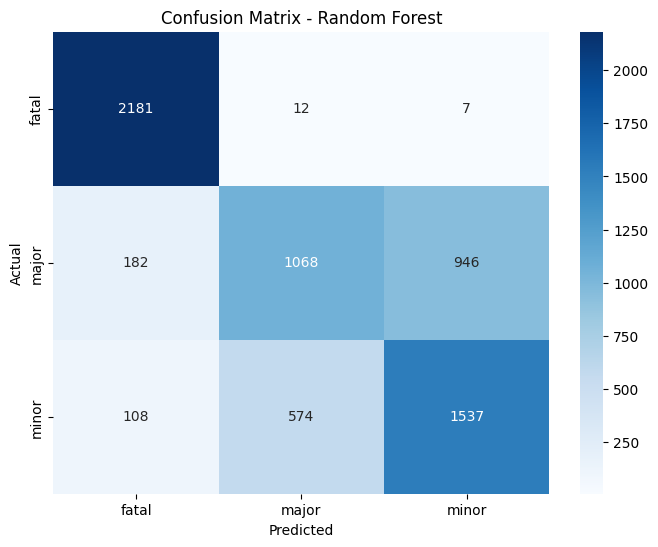

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
print(f"{'Actual':<15} {'Predicted':<15} {'Result':<10}")
print("-" * 40)

for actual, predicted in zip(y_test[:10], y_pred[:10]):
    actual_name    = le_target.classes_[actual]
    predicted_name = le_target.classes_[predicted]
    match = "Correct" if actual == predicted else "Wrong"
    print(f"{actual_name:<15} {predicted_name:<15} {match:<10}")

Actual          Predicted       Result    
----------------------------------------
minor           major           Wrong     
fatal           fatal           Correct   
fatal           fatal           Correct   
minor           minor           Correct   
minor           major           Wrong     
fatal           fatal           Correct   
major           major           Correct   
major           minor           Wrong     
minor           minor           Correct   
fatal           fatal           Correct   


In [49]:
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print("Model, Scaler and PCA saved successfully!")

Model, Scaler and PCA saved successfully!


In [50]:
model_info = {
    "features": list(X.columns),
    "target_classes": list(le_target.classes_),
    "categorical_columns": categorical_cols,
    "numerical_columns": ['temperature', 'casualties', 'vehicles_involved', 'risk_score', 'hour', 'lanes'],
    "engineered_features": ['risk_hour', 'high_traffic', 'multi_vehicle', 'bad_weather'],
    "n_pca_components": int(X_pca.shape[1]),
    "model_accuracy": round(accuracy_score(y_test, y_pred)*100, 2)
}

with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Model info saved to model_info.json!")
print(json.dumps(model_info, indent=4))

Model info saved to model_info.json!
{
    "features": [
        "hour",
        "day_of_week",
        "is_weekend",
        "road_type",
        "lanes",
        "traffic_signal",
        "weather",
        "visibility",
        "temperature",
        "traffic_density",
        "cause",
        "vehicles_involved",
        "casualties",
        "is_peak_hour",
        "festival",
        "risk_score",
        "risk_hour",
        "high_traffic",
        "multi_vehicle",
        "bad_weather"
    ],
    "target_classes": [
        "fatal",
        "major",
        "minor"
    ],
    "categorical_columns": [
        "day_of_week",
        "road_type",
        "weather",
        "visibility",
        "traffic_density",
        "cause",
        "festival"
    ],
    "numerical_columns": [
        "temperature",
        "casualties",
        "vehicles_involved",
        "risk_score",
        "hour",
        "lanes"
    ],
    "engineered_features": [
        "risk_hour",
        "high_tra